# Naive Bayes

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [12]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter

from sklearn.datasets import make_classification
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from models.naive_bayes import NaiveBayes

from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from utils.plots import plot_decision_boundary

## Dataset 1

In [ ]:
# Generation
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    class_sep=1.5,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

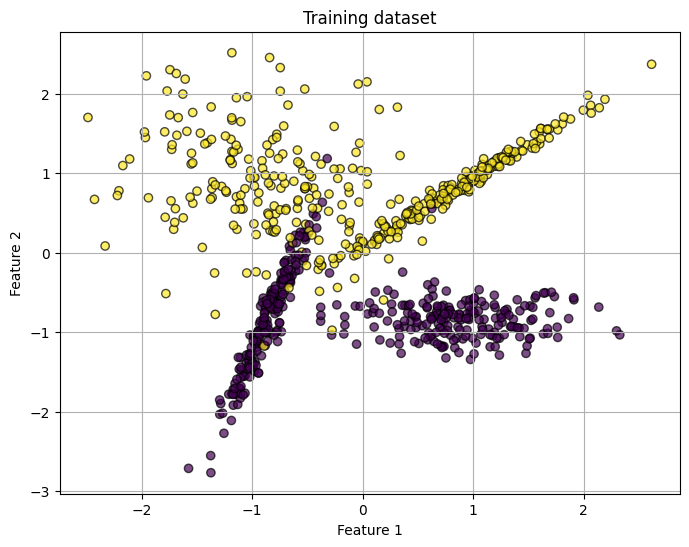

In [5]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

### Fitting

In [6]:
scratch_nb = NaiveBayes()
sklearn_nb = GaussianNB()

In [7]:
models = {
    "From scratch": scratch_nb,
    "Scikit-learn": sklearn_nb,
}

results = {}

for name, model in models.items():
    start = perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = perf_counter() - start

    start = perf_counter()
    preds = model.predict(X_test_scaled)
    predict_time = perf_counter() - start

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Fit time": fit_time,
        "Predict time": predict_time,
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Fit time,Predict time
From scratch,0.925,0.929293,0.92,0.924623,0.009120,0.040220
Scikit-learn,0.925,0.929293,0.92,0.924623,0.036439,0.001535


### Decision Boundary Plots
Since the decision rule for Naive Bayes is based on the product of a series of gaussian terms, with quadratic terms in the exponent, the decision boundary is generally quadratic/curved, rather than a straight line.

Also, NB assumes that features are conditionally independent given the class. Looking at the scatter plot, that is clearly not true, as the classes contain elongated structures and correlation, yet NB still works well. This is one of the reasons this model became famous.

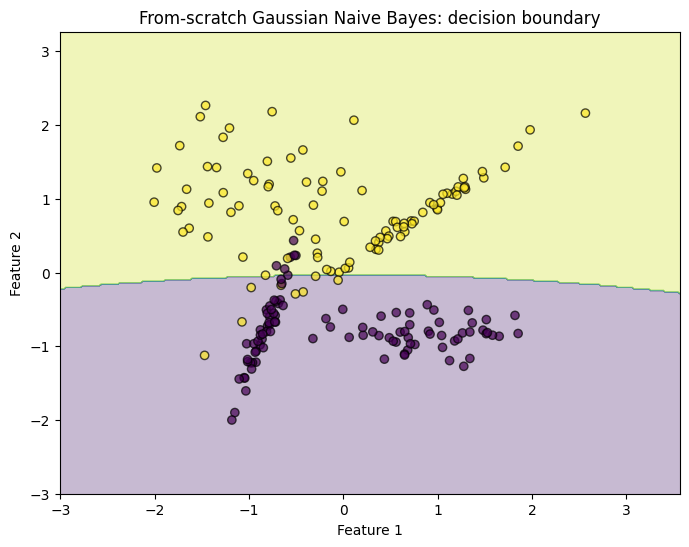

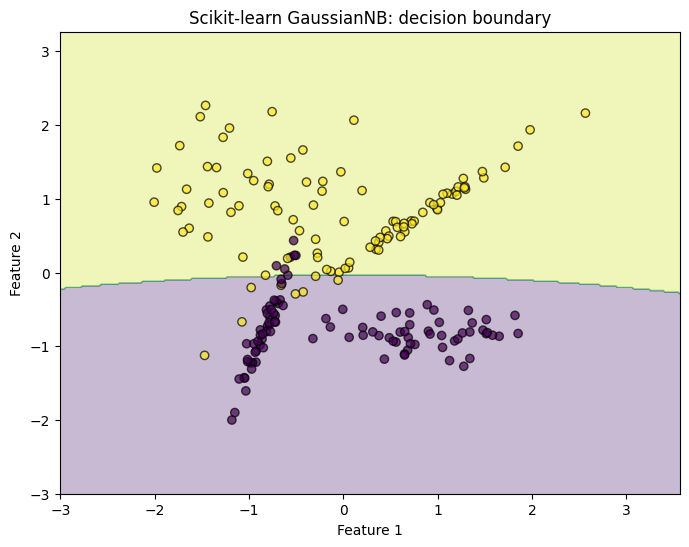

In [10]:
plot_decision_boundary(
    scratch_nb,
    X_test_scaled,
    y_test,
    "From-scratch Gaussian Naive Bayes: decision boundary"
)

plot_decision_boundary(
    sklearn_nb,
    X_test_scaled,
    y_test,
    "Scikit-learn GaussianNB: decision boundary"
)

### Learned Parameters

In [11]:
print("Class priors:")
print(scratch_nb._priors)

print("\nMeans:")
print(scratch_nb._mean)

print("\nVariances:")
print(scratch_nb._var)

Class priors:
[0.4975 0.5025]

Means:
[[ 0.00724931 -0.83943441]
 [-0.00717717  0.83108182]]

Variances:
[[0.88980698 0.24497083]
 [1.10899303 0.35918077]]


## Dataset 2
This dataset violates the independency assumption more strongly, and as such NB performs worse than another model such as KNN. The class distributions are highly non-Gaussian.

In [13]:
# Generation
X, y = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42,
)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

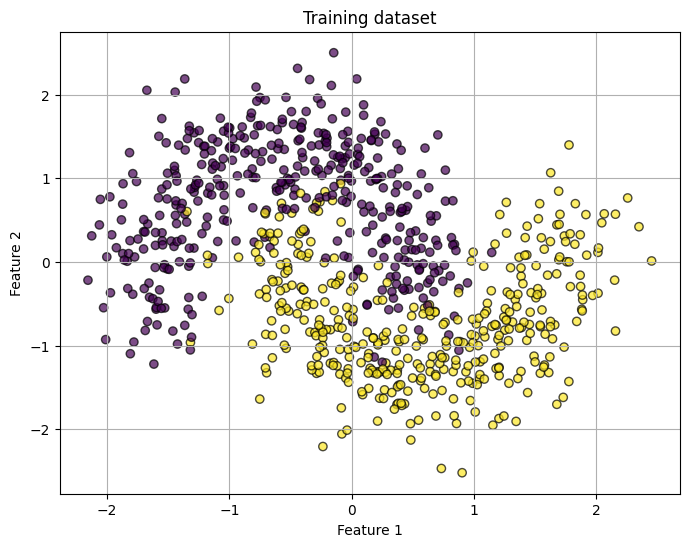

In [14]:
# Plotting
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    edgecolor="k",
    alpha=0.7,
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

### Fitting

In [15]:
scratch_nb = NaiveBayes()
sklearn_nb = GaussianNB()

In [16]:
models = {
    "From scratch": scratch_nb,
    "Scikit-learn": sklearn_nb,
}

results = {}

for name, model in models.items():
    start = perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = perf_counter() - start

    start = perf_counter()
    preds = model.predict(X_test_scaled)
    predict_time = perf_counter() - start

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Fit time": fit_time,
        "Predict time": predict_time,
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Fit time,Predict time
From scratch,0.915,0.936842,0.89,0.912821,0.001189,0.023241
Scikit-learn,0.915,0.936842,0.89,0.912821,0.004050,0.000609


### Decision Boundary Plots

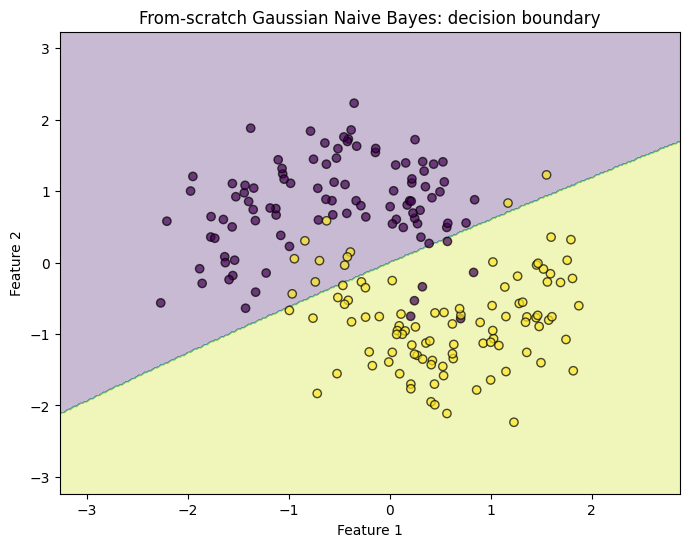

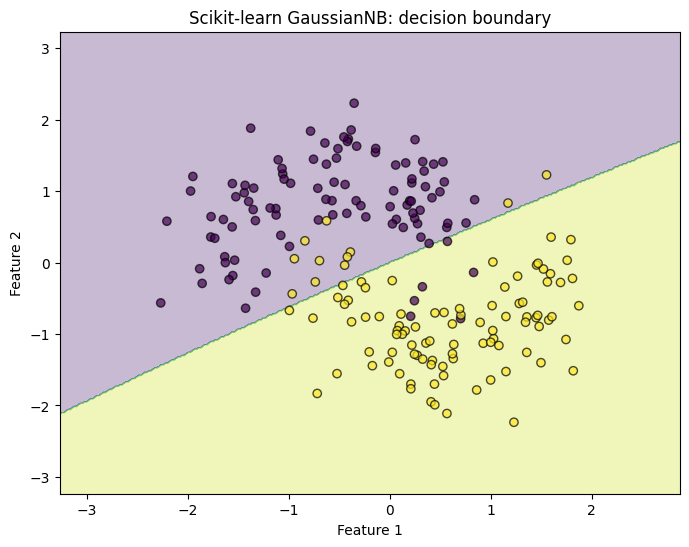

In [17]:
plot_decision_boundary(
    scratch_nb,
    X_test_scaled,
    y_test,
    "From-scratch Gaussian Naive Bayes: decision boundary"
)

plot_decision_boundary(
    sklearn_nb,
    X_test_scaled,
    y_test,
    "Scikit-learn GaussianNB: decision boundary"
)